# single subject application

In [1]:
# from new_model_exp import *
# -*- coding: utf-8 -*-
from typing import Tuple, Dict

from sklearn.metrics import f1_score, precision_score, recall_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data import DataLoader, TensorDataset

import scipy
import scipy.io

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import numpy as np
import platform, os

import matplotlib.pyplot as plt
import seaborn as sn

In [3]:
class EMGPreproc(nn.Module):
    """
    Вход:  x (B, C, T)
    Выход: y (B, C*T_out)
    """
    def __init__(self, n_channels: int,
                 k1: int = 51, k2: int = 51,           # length of 2 FIR-nuclei (odd)
                 k3: int = 51,
                 env_kernel: int = 101,                
                 r_min: float = 10.0,
                 r_max: float = 100.0,                  
                 init_w1: torch.Tensor | None = None,
                 init_w2: torch.Tensor | None = None,
                 init_w3: torch.Tensor | None = None
                 ):
        super().__init__()
        assert k1 % 2 == 1 and k2 % 2 == 1 and env_kernel % 2 == 1

        self.C = n_channels
        self.w1 = nn.Parameter(torch.randn(1, 1, k1) * 1e-3) # creates matrix of shape [1,1,k1], where k1 from with random numbers from a normal distribution with mean 0 and variance 1 and mutiply with 0.001
        self.w2 = nn.Parameter(torch.randn(1, 1, k2) * 1e-3)
        self.w3 = nn.Parameter(torch.randn(1, 1, k3) * 1e-3)

        if init_w1 is not None:
            self.w1.data.copy_(init_w1.view(1,1,-1))
        if init_w2 is not None:
            self.w2.data.copy_(init_w2.view(1,1,-1))
        if init_w3 is not None:
            self.w3.data.copy_(init_w3.view(1,1,-1))

        # r = 1 + softplus(p), затем clip до r_max
        self.p_r = nn.Parameter(torch.tensor(0.0))
        self.r_min = float(r_min)
        self.r_max = float(r_max)


    @staticmethod
    def _repeat_for_channels(w, C):
        return w.repeat(C, 1, 1)  # (C,1,K)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, T = x.shape
        assert C == self.C, f"expected {self.C} channels, got {C}"

        y1 = F.conv1d(x, self._repeat_for_channels(self.w1, C),
                      padding=self.w1.size(-1)//2, groups=C)
        y2 = F.conv1d(x, self._repeat_for_channels(self.w2, C),
                      padding=self.w2.size(-1)//2, groups=C)
        y3 = F.conv1d(x, self._repeat_for_channels(self.w3, C),
                      padding=self.w3.size(-1)//2, groups=C)
        y = y1 + y2 + y3 

        env = torch.abs(y)
        # env_out = env.reshape(B, C*T)
        env_out = env.reshape(B, C, T)

        return env_out

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import Optional

class EMGAugment(nn.Module):
    def __init__(self,
                 p_noise=0.8, noise_std=0.03,                 # 3% RMS
                 p_gain=0.8, gain_std=0.05, offset_std=0.02,  # ±5% gain, ±2% offset
                 p_shift=0.5, max_shift_ms=120, fs=1000,
                 p_ch_dropout=0.2, ch_drop_rate=0.125,         
                 p_ch_mix=0.3, mix_alpha=0.15,                # mix near chanels
                 p_tmask=0.3, tmask_ms=60,                    # mask by time
                 p_bandstop=0.0, f0=50.0, bw=2.0, fs_for_bs=None  # optional
                 ):
        super().__init__()
        self.p_noise = p_noise
        self.noise_std = noise_std
        self.p_gain  = p_gain
        self.gain_std  = gain_std
        self.offset_std = offset_std
        self.p_shift = p_shift
        self.max_shift = int(round(max_shift_ms * (fs/1000)))
        self.p_ch_dropout = p_ch_dropout
        self.ch_drop_rate = ch_drop_rate
        self.p_ch_mix = p_ch_mix
        self.mix_alpha = mix_alpha
        self.p_tmask = p_tmask
        self.tmask = int(round(tmask_ms * (fs/1000)))
        self.p_bandstop = p_bandstop
        self.f0 = f0
        self.bw = bw
        self.fs_for_bs = fs_for_bs or fs

    @staticmethod
    def _rand_mask_like(x, prob):
        if prob <= 0:
            return None
        return (torch.rand(x.size(0), 1, 1, device=x.device) < prob)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (B, C, T), float32, on every device.
        Return the same size augmentated tensor.
        """
        B, C, T = x.shape
        x_aug = x

        # 1) Additive noise
        if self.p_noise > 0:
            m = self._rand_mask_like(x_aug, self.p_noise)
            if m is not None:
                noise = self.noise_std * torch.randn_like(x_aug)
                x_aug = torch.where(m, x_aug + noise, x_aug)

        # 2) Per-channel gain/offset
        if self.p_gain > 0:
            m = self._rand_mask_like(x_aug, self.p_gain)
            if m is not None:
                gain = (1.0 + self.gain_std * torch.randn(B, C, 1, device=x_aug.device, dtype=x_aug.dtype))
                offs = (self.offset_std * torch.randn(B, C, 1, device=x_aug.device, dtype=x_aug.dtype))
                x_aug = torch.where(m, gain * x_aug + offs, x_aug)

        # 3) Time shift (roll)
        if self.p_shift > 0 and self.max_shift > 0:
            m = self._rand_mask_like(x_aug, self.p_shift)
            if m is not None:
                shifts = torch.randint(-self.max_shift, self.max_shift+1, (B,), device=x_aug.device)
                xa = []
                for i in range(B):
                    xi = x_aug[i]
                    xi = torch.roll(xi, int(shifts[i].item()), dims=-1)
                    xa.append(xi.unsqueeze(0))
                x_aug = torch.cat(xa, dim=0)

        # 4) Channel dropout
        if self.p_ch_dropout > 0 and self.ch_drop_rate > 0:
            if torch.rand(()) < self.p_ch_dropout:
                # mask
                drop_mask = (torch.rand(C, device=x_aug.device) < self.ch_drop_rate).float()
                x_aug = x_aug * (1.0 - drop_mask.view(1, C, 1))

        # 5) Channel mix (mix with shifted neighbors)
        if self.p_ch_mix > 0 and C > 1:
            if torch.rand(()) < self.p_ch_mix:
                alpha = self.mix_alpha
                # cycle shift  -> 1
                x_shift = torch.roll(x_aug, shifts=1, dims=1)
                x_aug = (1 - alpha) * x_aug + alpha * x_shift

        # 6) Time masking
        if self.p_tmask > 0 and self.tmask > 0:
            if torch.rand(()) < self.p_tmask:
                t0 = torch.randint(0, max(1, T - self.tmask + 1), (1,), device=x_aug.device).item()
                x_aug[:, :, t0:t0+self.tmask] = 0.0

        # 7) (Optional) Band-stop jitter
        if self.p_bandstop > 0 and torch.rand(()) < self.p_bandstop:
            k = max(3, int(round(self.fs_for_bs / (self.bw*4))))
            k = k if k % 2 == 1 else k+1
            kernel = torch.ones(1, 1, k, device=x_aug.device, dtype=x_aug.dtype) / k
            smooth = F.conv1d(x_aug, kernel.repeat(C,1,1), padding=k//2, groups=C)
            x_aug = x_aug - 0.3 * smooth

        return x_aug


In [6]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChannelCNN(nn.Module):
    """
    Deep version:
      - 1× pointwise:   (B, C,  T) -> (B, D,  T)
      - 1× depthwise s: (B, D,  T) -> (B, D, T')  (stride by time)
      - K×  DW-SEP blocks without alteration length and chanels: (B, D, T') -> (B, D, T')
    Exit: (B, D, T') — the same .size.
    """
    def __init__(self, in_ch, d_model, k=7, stride=2,
                 extra_layers: int = 2,      
                 k_inner: int = 5,           
                 dropout: float = 0.1):
        super().__init__()
        self.d_model = d_model

        # 1) mix chanel (pointwise)
        self.pw = nn.Conv1d(in_ch, d_model, kernel_size=1, bias=False)

        # 2)  depthwise with stride for make less T
        self.dw1 = nn.Conv1d(d_model, d_model, kernel_size=k, padding=k//2,
                             stride=stride, groups=d_model, bias=False)
        self.bn1 = nn.GroupNorm(1, d_model)
        self.act = nn.ELU()
        self.do  = nn.Dropout(dropout)

        # 3) stack extra residual-blocks (depthwise separable)
        blocks = []
        for _ in range(extra_layers):
            blocks.append(
                nn.Sequential(
                    # depthwise (without alteration length)
                    nn.Conv1d(d_model, d_model, kernel_size=k_inner,
                              padding=k_inner//2, groups=d_model, bias=False),
                    nn.GroupNorm(1, d_model),
                    nn.ELU(),
                    nn.Dropout(dropout),
                    # pointwise
                    nn.Conv1d(d_model, d_model, kernel_size=1, bias=False),
                    nn.GroupNorm(1, d_model),
                    nn.ELU(),
                    nn.Dropout(dropout),
                )
            )
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):                 # x: (B,C,T)
        z = self.pw(x)                    # (B,D,T)
        z = self.dw1(z)                   # (B,D,T')
        z = self.act(self.bn1(z))
        z = self.do(z)

        for blk in self.blocks:
            y = blk(z)                    # (B,D,T')
            z = z + y                     # residual
        return z                          # (B,D,T')

# --- 2) Sinosoidal position embedding ---
class SinusPE(nn.Module):
    def __init__(self, d_model, max_len=8192, p=0.1):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)
        self.drop = nn.Dropout(p)
    def forward(self, x):                # x: (B,T,D)
        T = x.size(1)
        return self.drop(x + self.pe[:T].unsqueeze(0).to(x.dtype))

# --- 3) Simple Transformer-classifier ---
class CNNTransformerClassifier(nn.Module):
    def __init__(self, in_ch: int, n_classes: int,
                 d_model: int = 4,
                 n_heads: int = 2,
                 ff_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.1, k_cnn: int = 7, stride_cnn: int = 2,
                #  pool: str = 'attn'
                 ):
        super().__init__()
        self.pre = EMGPreproc(n_channels=in_ch, k1=21, k2=51, k3=71, env_kernel=101) # x: (B,C,T) -> (B,C,T)
        self.cnn = ChannelCNN(in_ch, d_model, k=k_cnn, stride=stride_cnn,
                              dropout=0.1
                              )    # (B,C,T) -> (B,D,T')
        self.pe  = SinusPE(d_model, p=dropout) # -> (B,D,T')
        # self.pool = pool
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation='relu'
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.cls = nn.Sequential(
            nn.LazyLinear(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
            )
    def forward(self, x):                # x: (B,C,T)
        z = self.pre(x)                  # (B,C,T)
        z = self.cnn(z)                  # (B,D,T′)

        z = z.transpose(1, 2)            # -> (B,T′,D) 
        z = self.pe(z)
        z = self.encoder(z)              # (B,T′,D)

        B, T_, D = z.shape
        z = z.reshape(B, T_ * D)         # (B, T′*D)

        return self.cls(z)           

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import scipy.io

def exetrain(X_train, X_val, X_test, y_train, y_val, y_test, device, fs, n_epochs, n_s_current):
    # 1. DATA PREPARATION
    ds_tr = TensorDataset(X_train, y_train)
    ds_val = TensorDataset(X_val, y_val)
    ds_te  = TensorDataset(X_test, y_test)

    dl_tr = DataLoader(ds_tr, batch_size=32, shuffle=True)
    dl_val= DataLoader(ds_val, batch_size=64, shuffle=False)
    dl_te = DataLoader(ds_te,  batch_size=64, shuffle=False)

    # 2. MODEL INITIALIZATION
    C = X_train.size(1)
    model = CNNTransformerClassifier(
        in_ch=C, n_classes=10, 
        d_model=4, n_heads=2, ff_dim=128,
        num_layers=2, dropout=0.3,
        k_cnn=21, stride_cnn=8
    ).to(device)

    augment = EMGAugment(fs=fs).to(device)
    crit = nn.CrossEntropyLoss()
    opt  = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    # 3. Variables for study control
    best_val_loss = float("inf")
    best_state = None
    patience = 70 
    patience_counter = 0
    
    # Dict for collecting study history (for graph)
    history = {
        'train_loss': [], 'val_loss': [], 
        'train_acc': [], 'val_acc': []
    }

    # 4. Cycles
    for epoch in range(1, n_epochs + 1):
        # --- TRAIN BLOCK ---
        model.train()
        tr_run_loss = 0.0
        tr_correct = 0
        tr_seen = 0
        
        for xb, yb in dl_tr:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            xb = augment(xb)

            opt.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tr_run_loss += float(loss) * xb.size(0)
            tr_correct += int((logits.argmax(1) == yb).sum())
            tr_seen += xb.size(0)
            
        tr_loss = tr_run_loss / max(1, tr_seen)
        tr_acc  = tr_correct / max(1, tr_seen)

        # --- VAL BLOCK ---
        model.eval()
        v_run_loss = 0.0
        v_correct = 0
        v_seen = 0
        
        with torch.no_grad():
            for xb, yb in dl_val:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logits = model(xb)
                loss = crit(logits, yb)
                v_run_loss += float(loss) * xb.size(0)
                v_correct += int((logits.argmax(1) == yb).sum())
                v_seen += xb.size(0)
                
        v_loss = v_run_loss / max(1, v_seen)
        v_acc  = v_correct / max(1, v_seen)
        
        # Reload LR
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(v_acc)

        # EARLY STOPPING 
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if epoch % 20 == 0:
            print(f"S{n_s_current} | Эпоха {epoch:03d}: "
                  f"TrLoss={tr_loss:.4f}, ValLoss={v_loss:.4f} | "
                  f"TrAcc={tr_acc:.3f}, ValAcc={v_acc:.3f}")

        if patience_counter >= patience:
            print(f"Early stopping на {epoch} эпохе. Best Val Loss: {best_val_loss:.4f}")
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    
    model.eval()
    t_correct, t_seen = 0, 0
    all_logits, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in dl_te:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            logits = model(xb)
            t_correct += int((logits.argmax(1) == yb).sum())
            t_seen += xb.size(0)
            all_logits.append(logits.argmax(1).cpu().numpy())
            all_labels.append(yb.cpu().numpy())
        
    test_acc = t_correct / max(1, t_seen)
    print(f"--- РЕЗУЛЬТАТ ТЕСТА S{n_s_current}: {test_acc:.3f} ---")
    
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    scipy.io.savemat(f'results_subject_{n_s_current}.mat', 
                     {'y_true': all_labels, 'y_pred': all_logits})
    
    return test_acc, history

In [8]:
data = scipy.io.loadmat('/kaggle/input/datasets/skmrel/lebedev-model12/dataset.mat')
# data_f = scipy.io.loadmat('F:/emg_writing/dataset.mat')
subs = np.load('/kaggle/input/datasets/skmrel/lebedev-model12/sub_marks.npy')


РАБОТА С СУБЪЕКТОМ 0

--- Субъект 0, Фолд 1/5 ---


/tmp/ipykernel_55/4279257425.py:62: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tr_run_loss += float(loss) * xb.size(0)


S0 | Эпоха 020: TrLoss=0.8445, ValLoss=0.7022 | TrAcc=0.668, ValAcc=0.744
S0 | Эпоха 040: TrLoss=0.5912, ValLoss=0.5801 | TrAcc=0.788, ValAcc=0.800
S0 | Эпоха 060: TrLoss=0.4222, ValLoss=0.6543 | TrAcc=0.858, ValAcc=0.789
S0 | Эпоха 080: TrLoss=0.4385, ValLoss=0.8104 | TrAcc=0.852, ValAcc=0.756
S0 | Эпоха 100: TrLoss=0.7673, ValLoss=0.7722 | TrAcc=0.838, ValAcc=0.833
S0 | Эпоха 120: TrLoss=0.2703, ValLoss=0.7426 | TrAcc=0.916, ValAcc=0.856
Early stopping на 137 эпохе. Best Val Loss: 0.5020
--- РЕЗУЛЬТАТ ТЕСТА S0: 0.780 ---

--- Субъект 0, Фолд 2/5 ---
S0 | Эпоха 020: TrLoss=0.6463, ValLoss=1.8648 | TrAcc=0.802, ValAcc=0.633
S0 | Эпоха 040: TrLoss=0.4148, ValLoss=1.6986 | TrAcc=0.849, ValAcc=0.733
S0 | Эпоха 060: TrLoss=0.3491, ValLoss=1.9124 | TrAcc=0.877, ValAcc=0.733
S0 | Эпоха 080: TrLoss=0.3038, ValLoss=1.9997 | TrAcc=0.888, ValAcc=0.722
Early stopping на 80 эпохе. Best Val Loss: 1.0745
--- РЕЗУЛЬТАТ ТЕСТА S0: 0.880 ---

--- Субъект 0, Фолд 3/5 ---
S0 | Эпоха 020: TrLoss=0.7788, Va

TypeError: unhashable type: 'dict'

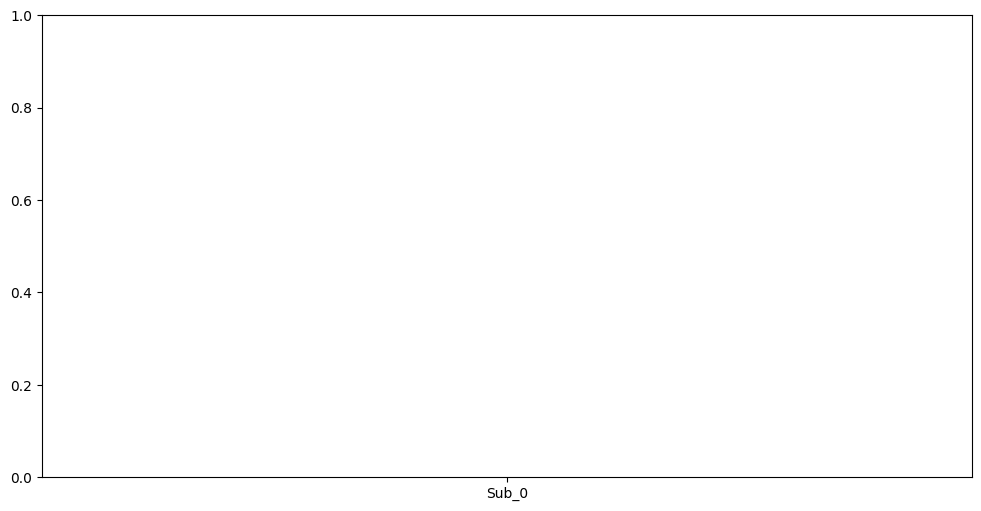

In [9]:

from sklearn.model_selection import StratifiedKFold
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

n_epochs_max = 500
n_folds = 5
fs = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
subject_cv_results = {} 

for n_s in range(11):
    print(f"\n{'='*20}\nWotk with subject {n_s}\n{'='*20}")
    
    X_sub = np.transpose(data['data'], (0,2,1))[subs==n_s]
    y_sub = np.squeeze(data['label'])[subs==n_s]
    X_sub = np.nan_to_num(X_sub)
    
    X_work, X_test_final, y_work, y_test_final = train_test_split(
        X_sub, y_sub, test_size=0.1, stratify=y_sub, random_state=42
    )
    
    fold_accuracies = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_work, y_work)):
        print(f"\n--- Subject {n_s}, Fold {fold+1}/{n_folds} ---")
        
        X_tr_f, X_val_f = X_work[train_idx], X_work[val_idx]
        y_tr_f, y_val_f = y_work[train_idx], y_work[val_idx]
        
        X_tr = torch.tensor(X_tr_f, dtype=torch.float32)
        X_va = torch.tensor(X_val_f, dtype=torch.float32)
        X_te = torch.tensor(X_test_final, dtype=torch.float32)
        
        y_tr = torch.tensor(y_tr_f, dtype=torch.long)
        y_va = torch.tensor(y_val_f, dtype=torch.long)
        y_te = torch.tensor(y_test_final, dtype=torch.long)
        
        acc = exetrain(X_tr, X_va, X_te, y_tr, y_va, y_te, device, fs, n_epochs_max, n_s)
        fold_accuracies.append(acc)
    
    subject_cv_results[f"Sub_{n_s}"] = fold_accuracies


df_res = pd.DataFrame(subject_cv_results)
df_melted = df_res.melt(var_name='Subject', value_name='Accuracy')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Subject', y='Accuracy', palette='viridis')
sns.stripplot(data=df_melted, x='Subject', y='Accuracy', color='black', alpha=0.5)
plt.title(f'Cross-Validation Accuracy ({n_folds} folds) per Subject')
plt.axhline(y=df_melted['Accuracy'].mean(), color='r', linestyle='--', label=f"Mean: {df_melted['Accuracy'].mean():.3f}")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

print("\nStatistics:")
summary = df_res.describe().T[['mean', 'std', 'min', 'max']]
print(summary)

In [16]:
display(accs)
display(np.mean(accs))

NameError: name 'accs' is not defined

In [ ]:
print("\n" + "="*30)
print("(Mean ± STD)")
for s, (m, std) in all_results.items():
    print(f"Subject {s}: {m:.4f} ± {std:.4f}")

cm = confusion_matrix(y_true_all, y_pred_all)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Confusion Matrix')
plt.show()

In [10]:
res_kfold_500 = summary['mean'].tolist()
res_kfold_500

NameError: name 'summary' is not defined

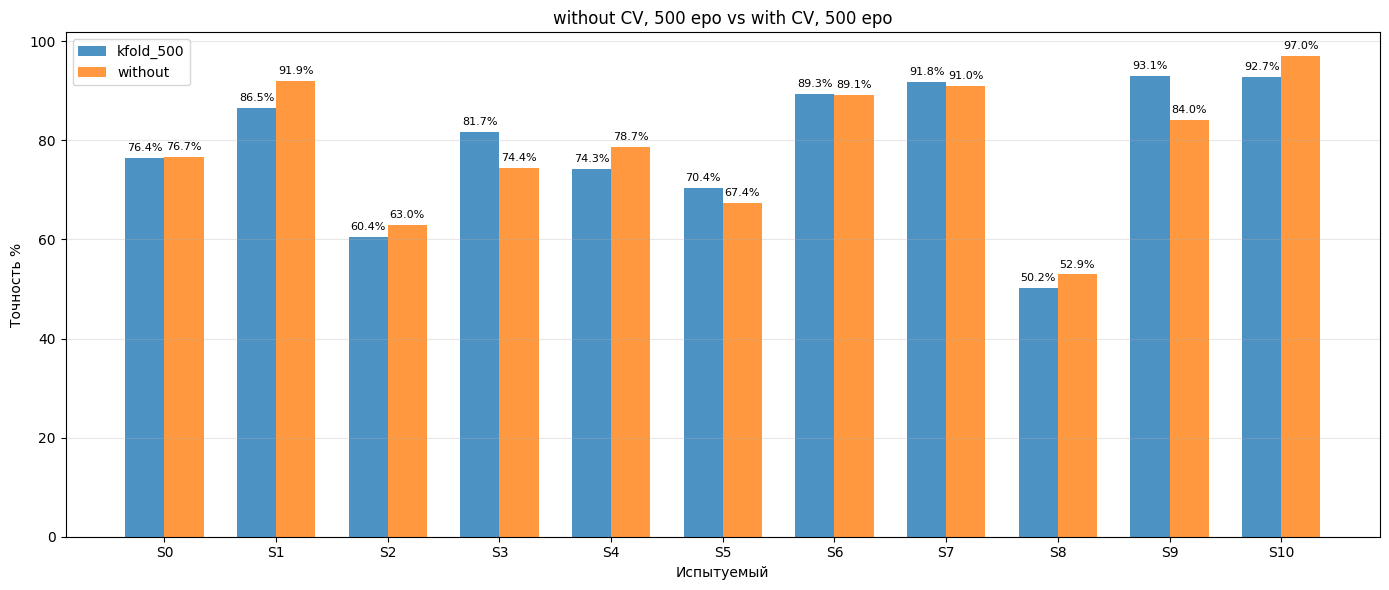


сравним модельки

Классическая модель: Среднее: 78.81%, Std: 13.47%
End-to-End модель: Среднее: 78.74%, Std: 13.00%

Статистическое сравнение (парный t-тест):
  t-статистика: 0.049
  p-значение: 0.9616
Различие НЕ является статистически значимым


In [29]:
# Classic_approach_results
end_to_end_accs = [0.7666666666666667,
 0.9191919191919192,
 0.6296296296296297,
 0.7441860465116279,
 0.7865168539325843,
 0.6741573033707865,
 0.8910891089108911,
 0.9101123595505618,
 0.5294117647058824,
 0.8404255319148937,
 0.9696969696969697]

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(11)
width = 0.35

bars1 = ax.bar(x - width/2, [a*100 for a in res_kfold_500], width, label="kfold_500", alpha=0.8)
bars2 = ax.bar(x + width/2, [a*100 for a in end_to_end_accs], width, label='without', alpha=0.8)
ax.set_xlabel('Испытуемый')
ax.set_ylabel("Точность %")
ax.set_title("without CV, 500 epo vs with CV, 500 epo")
ax.set_xticks(x)
ax.set_xticklabels([f'S{i}' for i in range(11)])
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Статистическое сравнение по угару
from scipy import stats

print("\nсравним модельки\n")
print(f"Классическая модель: Среднее: {np.mean(res_kfold_500)*100:.2f}%, Std: {np.std(res_kfold_500)*100:.2f}%")
print(f"End-to-End модель: Среднее: {np.mean(end_to_end_accs)*100:.2f}%, Std: {np.std(end_to_end_accs)*100:.2f}%")

# t-тест для связанных выборок
t_stat, p_value = stats.ttest_rel([a*100 for a in res_kfold_500], [a*100 for a in end_to_end_accs])
print(f"\nСтатистическое сравнение (парный t-тест):")
print(f"  t-статистика: {t_stat:.3f}")
print(f"  p-значение: {p_value:.4f}")
if p_value < 0.05:
    print("Различие статистически значимо (p < 0.05)")
else:
    print("Различие НЕ является статистически значимым")

In [ ]:
np.mean([0.8222222222222222,
 0.8585858585858586,
 0.7283950617283951,
 0.7790697674418605,
 0.7752808988764045,
 0.6629213483146067,
 0.8712871287128713,
 0.9101123595505618,
 0.6823529411764706,
 0.9468085106382979,
 0.8383838383838383])

In [ ]:
# model.eval()
#кусок кода из функции выше, не робит
#tloss = 0.0
#tcorrect = 0
#tseen = 0
#all_logits = []
#all_labels = []
#with torch.no_grad():
#    for xb, yb in dl_te:
  #      xb = xb.to(device, non_blocking=True)
 #       yb = yb.to(device, non_blocking=True)
   #     logits = model(xb)
    #    loss = crit(logits, yb)
     #   tloss += float(loss) * xb.size(0)
      #  tcorrect += int((logits.argmax(1) == yb).sum())
       # tseen += xb.size(0)
        #all_logits.append(logits.argmax(1).cpu().numpy())
        #all_labels.append(yb.cpu().numpy())
#print(f"TEST | loss {tloss/max(1,tseen):.4f} | acc {tcorrect/max(1,tseen):.3f}")

#all_logits = np.concatenate(all_logits, axis=0)   # shape: (N_test, n_classes)
#all_labels = np.concatenate(all_labels, axis=0)   # shape: (N_test,)

#scipy.io.savemat(f'y_true_pred_singlsub_s{n_s}.mat', {'y_true': all_labels,
                                              'y_pred': all_logits})

Загружен файл nn_results_s0.mat
Загружен файл nn_results_s1.mat
Загружен файл nn_results_s2.mat
Загружен файл nn_results_s3.mat
Загружен файл nn_results_s4.mat
Загружен файл nn_results_s5.mat
Загружен файл nn_results_s6.mat
Загружен файл nn_results_s7.mat
Загружен файл nn_results_s8.mat
Загружен файл nn_results_s9.mat
Загружен файл nn_results_s10.mat
Всего: 556
Уникальные метки: [0 1 2 3 4 5 6 7 8 9]


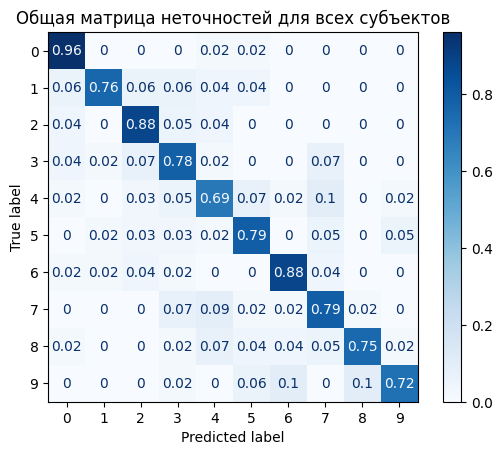


Абсолютные значения:
 [[55  0  0  0  1  1  0  0  0  0]
 [ 3 41  3  3  2  2  0  0  0  0]
 [ 2  0 49  3  2  0  0  0  0  0]
 [ 2  1  4 43  1  0  0  4  0  0]
 [ 1  0  2  3 40  4  1  6  0  1]
 [ 0  1  2  2  1 46  0  3  0  3]
 [ 1  1  2  1  0  0 49  2  0  0]
 [ 0  0  0  4  5  1  1 44  1  0]
 [ 1  0  0  1  4  2  2  3 42  1]
 [ 0  0  0  1  0  3  5  0  5 36]]


In [31]:
all_labels_combined = []
all_logits_combined = []

for n_s in range(11):
    filename = f'nn_results_s{n_s}.mat'
    try:
        data = scipy.io.loadmat(filename)
        all_labels_combined.append(data['y_true'].flatten())  # .flatten() чтобы убедиться, что это 1D
        all_logits_combined.append(data['y_pred'].flatten())
        print(f"Загружен файл {filename}")
    except FileNotFoundError:
        print(f"Файл {filename} не найден")

if all_labels_combined:
    all_labels = np.concatenate(all_labels_combined)
    all_logits = np.concatenate(all_logits_combined)
    
    print(f"Всего: {len(all_labels)}")
    print(f"Уникальные метки: {np.unique(all_labels)}")
    
    # Создаем матрицу неточностей
    cm = confusion_matrix(all_labels, all_logits)
    
    # Нормализуем матрицу (по строкам)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.round(cm_normalized, 2)

    disp = ConfusionMatrixDisplay(cm_normalized)
    disp.plot(cmap=plt.cm.Blues)
    plt.title('Общая матрица неточностей для всех субъектов')
    plt.show()
    
    print("\nАбсолютные значения:\n", cm)